In [1]:
import sys
sys.path.append('../../')

In [2]:
# 데이터 처리
import numpy as np
import pandas as pd

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 모델링 및 교차 검증
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold

# 평가 지표
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve

import xgboost as xgb

# 유틸함수
from src.utils.model_manager import ModelManager
from src.utils.plot_config import set_korean_font

In [3]:
set_korean_font()

# 모든 난수에 동일한 시드 적용
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

[PLOT_CONFIG] OS='Darwin' → 'AppleGothic' font will be used for Korean text.


In [4]:
df = pd.read_csv('../../data/processed/ljh_preprocessed.csv')
df.head()

,user_id,country_id,gender,age_group,reg_date,first_deposit,first_bet,fixed_bet_amount,live_bet_amount,total_bet_amount,...,fixed_hit_days,live_hit_days,total_hit_days,fixed_win_rate,live_win_rate,total_win_rate,fixed_avg_roi,live_avg_roi,total_avg_roi,churn
0,1324354,276.0,1.0,3.0,2005-02-01,2005-02-24,2005-02-24,15750.38,2146.47,17896.85,...,93.0,22.0,29.0,0.24,0.42,0.27,-0.00,-0.09,-0.08,0
1,1324355,300.0,1.0,1.0,2005-02-01,2005-02-01,2005-02-01,639.30,24.70,664.00,...,15.0,1.0,1.0,0.14,0.14,0.20,0.17,-0.76,-0.77,0
2,1324356,276.0,1.0,2.0,2005-02-01,2005-02-01,2005-02-02,898.81,701.82,1600.63,...,12.0,18.0,18.0,0.12,0.26,0.33,0.38,-0.25,0.64,0
3,1324358,752.0,1.0,1.0,2005-02-01,2005-02-01,2005-02-01,247.70,88.59,336.29,...,1.0,1.0,1.0,0.00,0.00,0.00,-0.88,-0.37,-0.54,1
4,1324360,792.0,1.0,2.0,2005-02-01,2005-02-02,2005-02-02,685.94,6.66,692.61,...,14.0,2.0,3.0,0.14,0.25,0.50,0.89,-0.63,6.99,0


## 1. 데이터 검사

### 클래스 불균형 및 가중치 설정

- **분포**: 잔류(33,322) vs 이탈(13,017)
- **이탈률**: 28.1% (불균형 비율 약 **1 : 2.6**)
- **모델 설정**: `scale_pos_weight = 2.6` 적용
  - **이유**: 소수 클래스(이탈)에 대한 학습 가중치를 높여 재현율(Recall) 극대화 및 모델 편향 방지


In [5]:
# 데이터 타입
df.dtypes

user_id                int64
country_id           float64
gender               float64
age_group            float64
reg_date                 str
first_deposit            str
first_bet                str
fixed_bet_amount     float64
live_bet_amount      float64
total_bet_amount     float64
fixed_win_amount     float64
live_win_amount      float64
total_win_amount     float64
fixed_bet_cnt        float64
live_bet_cnt         float64
total_bet_cnt        float64
fixed_active_days    float64
live_active_days     float64
total_active_days    float64
fixed_hit_days       float64
live_hit_days        float64
total_hit_days       float64
fixed_win_rate       float64
live_win_rate        float64
total_win_rate       float64
fixed_avg_roi        float64
live_avg_roi         float64
total_avg_roi        float64
churn                  int64
dtype: object

In [6]:
# 결측값 현황
null_cnt = df.isnull().sum()
null_pct = df.isnull().mean() * 100

null_df = pd.DataFrame({'결측 수': null_cnt, '결측률(%)': null_pct.round(2)})

missing = null_df[null_df['결측 수'] > 0].sort_values('결측률(%)', ascending=False)

print(missing if not missing.empty else '결측값 없음')

                    결측 수  결측률(%)
total_avg_roi      18175   39.22
total_win_rate     18175   39.22
total_hit_days     18175   39.22
live_avg_roi       14937   32.23
live_win_rate      14937   32.23
live_hit_days      14937   32.23
fixed_avg_roi        730    1.58
fixed_win_rate       730    1.58
fixed_hit_days       730    1.58
total_bet_cnt          2    0.00
total_active_days      2    0.00
live_active_days       2    0.00
fixed_active_days      2    0.00
country_id             2    0.00
gender                 2    0.00
fixed_bet_cnt          2    0.00
total_win_amount       2    0.00
live_win_amount        2    0.00
fixed_win_amount       2    0.00
total_bet_amount       2    0.00
live_bet_amount        2    0.00
fixed_bet_amount       2    0.00
first_bet              2    0.00
first_deposit          2    0.00
reg_date               2    0.00
age_group              2    0.00
live_bet_cnt           2    0.00


In [7]:
# churn 분포
churn_dist = df['churn'].value_counts().sort_index()
neg, pos = churn_dist[0], churn_dist[1]

print(churn_dist)
print(f'\n이탈율        : {pos / len(df) * 100:.1f}%')
print(f'불균형 비율    : 잔류({neg:,}) : 이탈({pos:,}) = {neg / pos:.1f} : 1')

churn
0    33322
1    13017
Name: count, dtype: int64

이탈율        : 28.1%
불균형 비율    : 잔류(33,322) : 이탈(13,017) = 2.6 : 1


## 2. 피처 엔지니어링


In [8]:
# 데이터셋 시작일
REF_DATE = pd.Timestamp('2005-02-01')

date_cols = ['reg_date', 'first_deposit', 'first_bet']
for col in date_cols:
  df[col] = pd.to_datetime(df[col], errors='coerce')

In [9]:
# 가입일 ~ 기준일 경과일
df['days_since_reg'] = (df['reg_date'] - REF_DATE).dt.days

# 가입 ~ 첫 입금까지 경과일
df['days_to_first_deposit'] = (df['first_deposit'] - df['reg_date']).dt.days

# 가입 ~ 첫 베팅까지 경과일
df['days_to_first_bet'] = (df['first_bet'] - df['reg_date']).dt.days

In [10]:
df.drop(columns=date_cols, inplace=True)

## 3. 결측값 처리


In [11]:
# y와 식별자 컬럼 제거
drop_cols = ['user_id', 'country_id', 'churn']

# X, y 분리
X = df.drop(columns=drop_cols)
y = df['churn']

high relation(>0.95) 피처 제거

- 두 feature 간 |r| > 0.95면 거의 동일한 정보로 간주
- 다중공산성 방지


In [12]:
corr_matrix = X.corr().abs()

# 중복쌍 제거
upper_tri = corr_matrix.where(
  np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_cols = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]

# high relation feature 제거
X = X.drop(columns=high_corr_cols)

# 최종 feature 확인
X.columns.tolist()

['gender',
 'age_group',
 'fixed_bet_amount',
 'live_bet_amount',
 'fixed_bet_cnt',
 'live_bet_cnt',
 'total_bet_cnt',
 'fixed_active_days',
 'live_active_days',
 'fixed_hit_days',
 'total_hit_days',
 'fixed_win_rate',
 'live_win_rate',
 'total_win_rate',
 'fixed_avg_roi',
 'live_avg_roi',
 'total_avg_roi',
 'days_since_reg',
 'days_to_first_deposit',
 'days_to_first_bet']

## 4. Train/Test 분리


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y,
  test_size=0.2,
  stratify=y,
  random_state=RANDOM_STATE
)

`scale_pos_weight` = 잔류(0) 수 / 이탈(1) 수

- XGBoost 손실 함수에서 이탈 샘플의 가중치를 높여 불균형을 보정함


In [14]:
neg_cnt = (y_train == 0).sum()
pos_cnt = (y_train == 1).sum()

scale_pos_weight = neg_cnt / pos_cnt
scale_pos_weight

np.float64(2.5597272901862875)

## 5. XGBoost train(Basic)

- Early Stopping 적용


In [15]:
xgb_base = xgb.XGBClassifier(
  n_estimators=500,
  max_depth=6,
  learning_rate=0.1,  # default
  scale_pos_weight=scale_pos_weight,
  eval_metric='logloss',  # early stopping 판단 기준 - 이진 cross-entropy 손실
  early_stopping_rounds=30, # 과적합 방지
  random_state=RANDOM_STATE
)

In [16]:
xgb_base.fit(
  X_train, y_train,
  eval_set=[(X_test, y_test)],
  verbose=100
)

print(f'최적 트리 수: {xgb_base.best_iteration}')

[0]	validation_0-logloss:0.64700
[100]	validation_0-logloss:0.36079
[200]	validation_0-logloss:0.35412
[300]	validation_0-logloss:0.35271
[313]	validation_0-logloss:0.35265
최적 트리 수: 283


In [17]:
# threshold=0.5
y_pred_base = xgb_base.predict(X_test)
y_proba_base = xgb_base.predict_proba(X_test)[:, 1]

In [18]:
print('=== Base XGBoost 모델 성능 ===')
print(classification_report(y_test, y_pred_base, target_names=['잔류(0)', '이탈(1)']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_base):.2f}')

=== Base XGBoost 모델 성능 ===
              precision    recall  f1-score   support

       잔류(0)       0.93      0.82      0.87      6665
       이탈(1)       0.65      0.83      0.73      2603

    accuracy                           0.83      9268
   macro avg       0.79      0.83      0.80      9268
weighted avg       0.85      0.83      0.83      9268

ROC-AUC: 0.92


## 6. 하이퍼파리미터 튜닝

### RandomizedSearchCV + StratifiedKFold

**선정 이유**

- `RandomizedSearchCV`: n_iter회 무작위 샘플링 -> 빠른 탐색 가능, 충분한 커버리지 기대
- `StratifiedKFold`: 불균형 데이터에서도 각 fold에 잔류/이탈 비율 유지 가능


In [19]:
param_dist = {
  'n_estimators': [100, 200, 300, 500],
  'max_depth': [3, 4, 5, 6, 8],
  'learning_rate': [0.01, 0.05, 0.1, 0.2],
  'min_child_weight': [1, 3, 5, 7], # 과적합 방지
  # L1 규제 (Lasso): 불필요한 피처의 가중치를 0으로 만드는 희소성 유도
  'reg_alpha':        [0, 0.01, 0.1, 1.0],
  # L2 규제 (Ridge): 가중치가 너무 커지지 않도록 억제 → 일반화 성능 향상
  'reg_lambda':       [1.0, 1.5, 2.0, 5.0],
}

In [20]:
xgb_cv = xgb.XGBClassifier(
  scale_pos_weight=scale_pos_weight,
  eval_metric='logloss',
  random_state=RANDOM_STATE,
  n_jobs=1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rs = RandomizedSearchCV(
  xgb_cv,
  param_distributions=param_dist,
  n_iter=50,
  scoring='roc_auc',
  cv=cv,
  verbose=1,
  random_state=RANDOM_STATE,
  n_jobs=-1
)

In [21]:
rs.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used h

In [22]:
print('\n=== 튜닝 결과 ===')
print('Best Params: ', rs.best_params_)
print(f'Best CV ROC-AUC: {rs.best_score_:.4f}')


=== 튜닝 결과 ===
Best Params:  {'reg_lambda': 5.0, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.1}
Best CV ROC-AUC: 0.9181


In [23]:
best_model    = rs.best_estimator_
y_pred_tuned  = best_model.predict(X_test)
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

In [24]:
print('\n=== ② 튜닝된 모델 성능 (threshold = 0.5) ===')
print(classification_report(y_test, y_pred_tuned, target_names=['잔류(0)', '이탈(1)']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_tuned):.4f}')


=== ② 튜닝된 모델 성능 (threshold = 0.5) ===
              precision    recall  f1-score   support

       잔류(0)       0.93      0.81      0.87      6665
       이탈(1)       0.63      0.86      0.73      2603

    accuracy                           0.82      9268
   macro avg       0.78      0.83      0.80      9268
weighted avg       0.85      0.82      0.83      9268

ROC-AUC : 0.9180


# 7. Threshold Optimization

| 임계값 방향 | Precision | Recall | 효과                                 |
| ----------- | --------- | ------ | ------------------------------------ |
| 낮춤 ↓      | ↓ 감소    | ↑ 증가 | 이탈 고객을 더 많이 잡음 (FN↓)       |
| 높임 ↑      | ↑ 증가    | ↓ 감소 | 이탈로 분류된 것의 정확도 높음 (FP↓) |


이탈 고객을 놓치는 비용(FN) > 잔류 고객 오분류 비용(FP)

-> **f1 기준** 최적 threshold 탐색


In [25]:
# 다양한 임계값에서 precision-recall 계산
precision_arr, recall_arr, thresh_arr = precision_recall_curve(
    y_test, y_proba_tuned
)

In [26]:
# 각 임계값에서 f1 계산
eps = 1e-8  # 0/0 방지
f1_arr = (
    2 * precision_arr[:-1] * recall_arr[:-1]
    / (precision_arr[:-1] + recall_arr[:-1] + eps)
)

In [27]:
best_thresh_idx = np.argmax(f1_arr)
best_threshold  = thresh_arr[best_thresh_idx]

In [28]:
print('=== 최적 임계값 탐색 결과 ===')
print(f'최적 임계값    : {best_threshold:.4f}  (기본값: 0.5000)')
print(f'해당 Precision : {precision_arr[best_thresh_idx]:.4f}')
print(f'해당 Recall    : {recall_arr[best_thresh_idx]:.4f}')
print(f'해당 F1        : {f1_arr[best_thresh_idx]:.4f}')

=== 최적 임계값 탐색 결과 ===
최적 임계값    : 0.5724  (기본값: 0.5000)
해당 Precision : 0.6780
해당 Recall    : 0.8144
해당 F1        : 0.7400


In [29]:
# 최적 임계값으로 최종 예측 (확률 >= best_threshold이면 이탈(1)로 분류)
y_pred_opt = (y_proba_tuned >= best_threshold).astype(int)

In [30]:
print(f'\n=== ③ 임계값 최적화 모델 성능 (threshold = {best_threshold:.4f}) ===')
print(classification_report(y_test, y_pred_opt, target_names=['잔류(0)', '이탈(1)']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_tuned):.4f}')


=== ③ 임계값 최적화 모델 성능 (threshold = 0.5724) ===
              precision    recall  f1-score   support

       잔류(0)       0.92      0.85      0.88      6665
       이탈(1)       0.68      0.81      0.74      2603

    accuracy                           0.84      9268
   macro avg       0.80      0.83      0.81      9268
weighted avg       0.85      0.84      0.84      9268

ROC-AUC : 0.9180


### 임계값에 따른 지표 변화 시각화


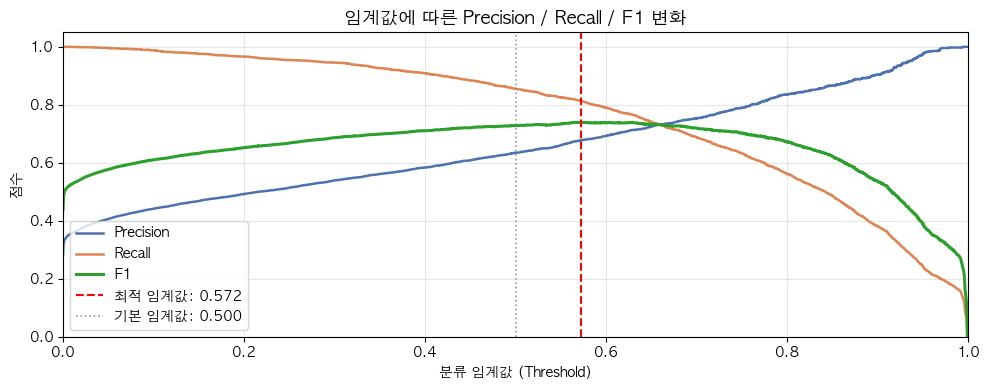

In [31]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresh_arr, precision_arr[:-1], label='Precision', color='#4C72B0', lw=1.8)
ax.plot(thresh_arr, recall_arr[:-1],    label='Recall',    color='#DD8452', lw=1.8)
ax.plot(thresh_arr, f1_arr,             label='F1',        color='#2CA02C', lw=2.2)

ax.axvline(x=best_threshold, color='red', linestyle='--', lw=1.5,
           label=f'최적 임계값: {best_threshold:.3f}')
ax.axvline(x=0.5, color='gray', linestyle=':', lw=1.2,
           label='기본 임계값: 0.500', alpha=0.8)

ax.set_xlabel('분류 임계값 (Threshold)')
ax.set_ylabel('점수')
ax.set_title('임계값에 따른 Precision / Recall / F1 변화', fontsize=13)
ax.legend(loc='lower left')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. 모델 성능 비교 & 최종 평가


In [32]:
def get_metrics(y_true, y_pred, y_proba, label):
    """모델 성능 지표를 딕셔너리로 반환"""
    return {
        '모델':      label,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_true, y_proba),
    }

In [33]:
results = [
    get_metrics(y_test, y_pred_base,  y_proba_base,
                '① 기본 XGBoost         (threshold=0.500)'),
    get_metrics(y_test, y_pred_tuned, y_proba_tuned,
                '② 튜닝 XGBoost         (threshold=0.500)'),
    get_metrics(y_test, y_pred_opt,   y_proba_tuned,
                f'③ 튜닝+임계값 최적화   (threshold={best_threshold:.3f})'),
]

results_df = pd.DataFrame(results).set_index('모델')

In [34]:
print('=== 모델별 성능 비교 ===')
print(results_df.to_string(float_format=lambda x: f'{x:.4f}'))

=== 모델별 성능 비교 ===
                                        Accuracy  Precision  Recall     F1  ROC-AUC
모델                                                                                 
① 기본 XGBoost         (threshold=0.500)    0.8261     0.6487  0.8306 0.7284   0.9154
② 튜닝 XGBoost         (threshold=0.500)    0.8211     0.6347  0.8552 0.7286   0.9180
③ 튜닝+임계값 최적화   (threshold=0.572)          0.8392     0.6780  0.8144 0.7400   0.9180


In [35]:
print('\n=== 지표별 최고 모델 ===')
for col in results_df.columns:
    best_idx = results_df[col].idxmax()
    print(f'  {col:10s}: {best_idx.strip()}  ({results_df.loc[best_idx, col]:.4f})')


=== 지표별 최고 모델 ===
  Accuracy  : ③ 튜닝+임계값 최적화   (threshold=0.572)  (0.8392)
  Precision : ③ 튜닝+임계값 최적화   (threshold=0.572)  (0.6780)
  Recall    : ② 튜닝 XGBoost         (threshold=0.500)  (0.8552)
  F1        : ③ 튜닝+임계값 최적화   (threshold=0.572)  (0.7400)
  ROC-AUC   : ② 튜닝 XGBoost         (threshold=0.500)  (0.9180)


In [36]:
# 최종 선택: F1 기준 최고 모델
final_model_label = results_df['F1'].idxmax()
print(f'최종 선택 모델 (F1 기준): {final_model_label.strip()}')


최종 선택 모델 (F1 기준): ③ 튜닝+임계값 최적화   (threshold=0.572)


In [37]:
print('\n=== 최종 선택 모델 상세 분류 ===')
print(classification_report(y_test, y_pred_opt, target_names=['잔류(0)', '이탈(1)']))


=== 최종 선택 모델 상세 분류 ===
              precision    recall  f1-score   support

       잔류(0)       0.92      0.85      0.88      6665
       이탈(1)       0.68      0.81      0.74      2603

    accuracy                           0.84      9268
   macro avg       0.80      0.83      0.81      9268
weighted avg       0.85      0.84      0.84      9268



# 9. 시각화

- ① Confusion Matrix (threshold 최적화 적용 모델)
  - 행: 실제값, 열: 예측값
  - TN(좌상): 잔류→잔류 (정답) FP(우상): 잔류→이탈 (오분류)
  - FN(좌하): 이탈→잔류 (누락) TP(우하): 이탈→이탈 (정답)
- ROC curve (base vs. 튜닝)
  - AUC가 1에 가까울수록 좋음
- PR curve


/Users/jpaper/Documents/study/sknetworks/00_hw/04_ml_projects/.venv/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/jpaper/Documents/study/sknetworks/00_hw/04_ml_projects/.venv/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


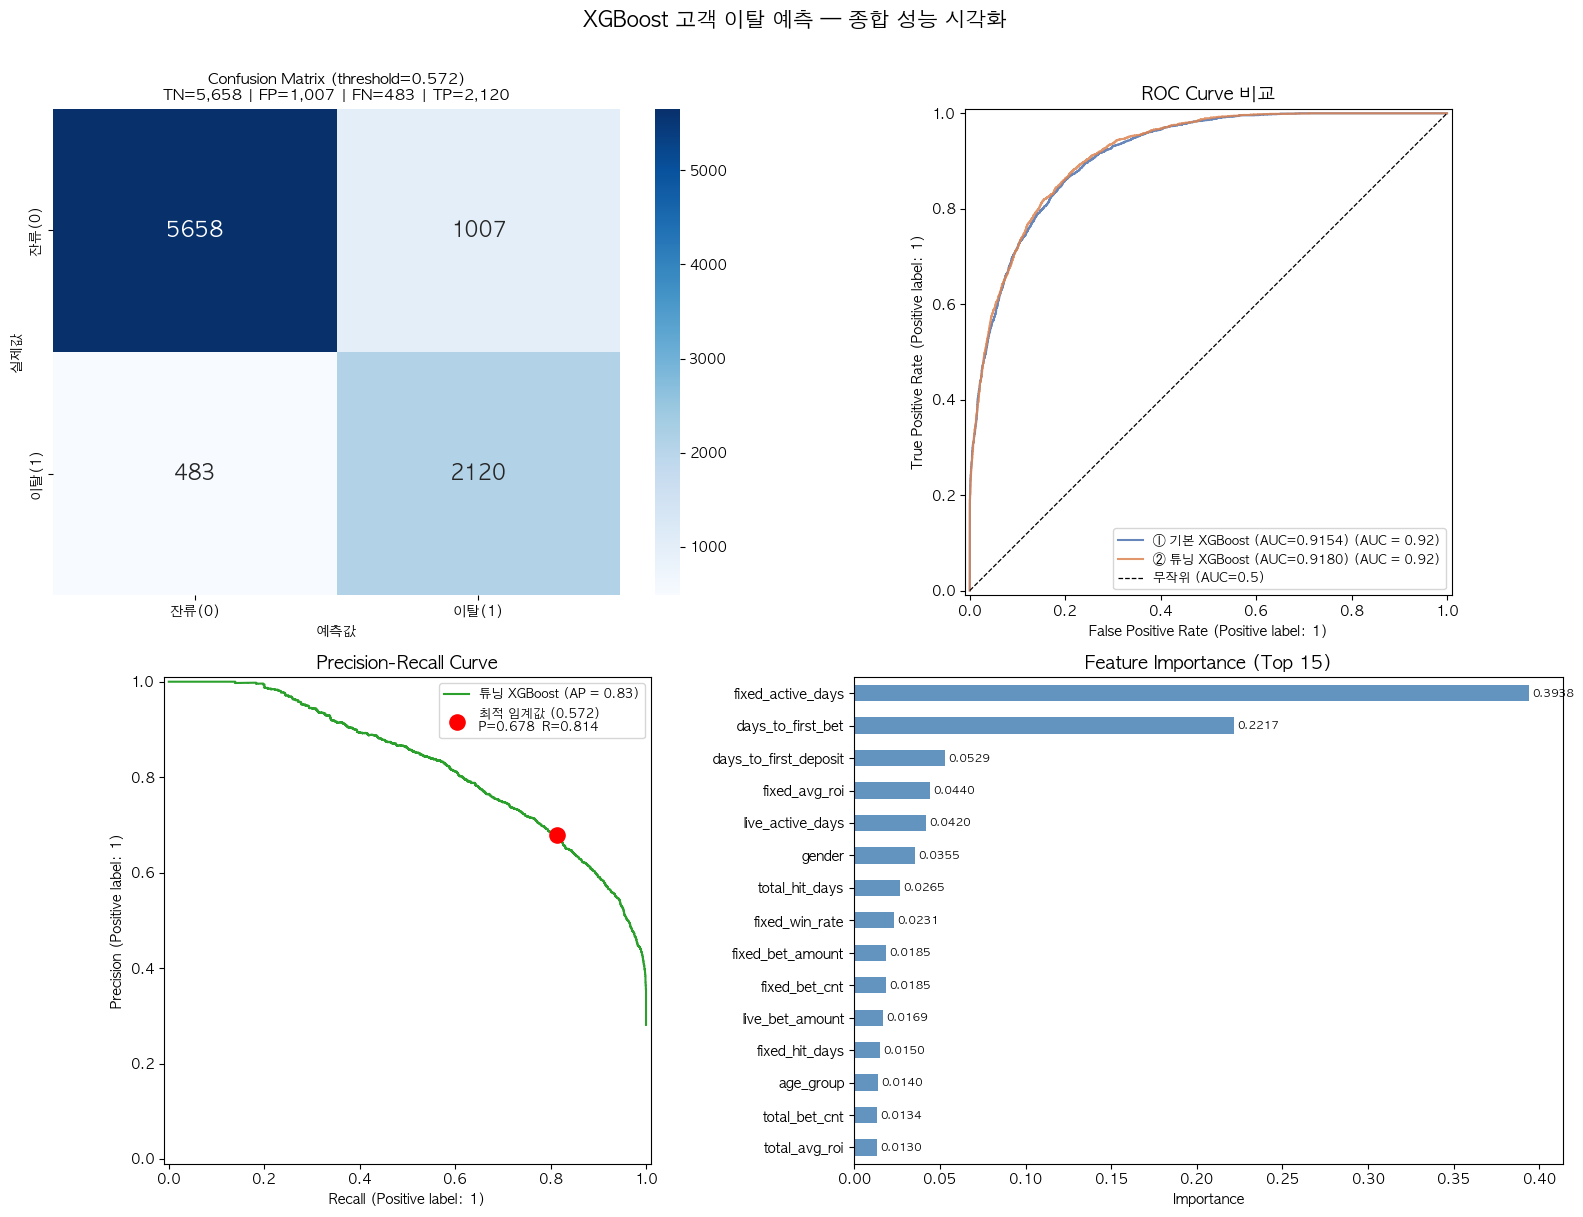

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# =============================
# Confusion Matrix
# =============================
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['잔류(0)', '이탈(1)'],
    yticklabels=['잔류(0)', '이탈(1)'],
    ax=axes[0, 0], annot_kws={'size': 15}
)
tn, fp, fn, tp = cm.ravel()
axes[0, 0].set_title(
    f'Confusion Matrix (threshold={best_threshold:.3f})\n'
    f'TN={tn:,} | FP={fp:,} | FN={fn:,} | TP={tp:,}',
    fontsize=11
)
axes[0, 0].set_xlabel('예측값')
axes[0, 0].set_ylabel('실제값')

# =============================
# ROC Curve
# =============================
auc_base  = roc_auc_score(y_test, y_proba_base)
auc_tuned = roc_auc_score(y_test, y_proba_tuned)
RocCurveDisplay.from_predictions(
    y_test, y_proba_base,
    name=f'① 기본 XGBoost (AUC={auc_base:.4f})',
    ax=axes[0, 1], color='#4C72B0', alpha=0.85
)
RocCurveDisplay.from_predictions(
    y_test, y_proba_tuned,
    name=f'② 튜닝 XGBoost (AUC={auc_tuned:.4f})',
    ax=axes[0, 1], color='#DD8452', alpha=0.85
)
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=0.9, label='무작위 (AUC=0.5)')
axes[0, 1].set_title('ROC Curve 비교', fontsize=13)
axes[0, 1].legend(loc='lower right', fontsize=9)

# =============================
# Precision-Recall Curve
# =============================
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba_tuned,
    name='튜닝 XGBoost',
    ax=axes[1, 0], color='#2CA02C'
)
axes[1, 0].scatter(
    recall_arr[best_thresh_idx], precision_arr[best_thresh_idx],
    color='red', s=120, zorder=5,
    label=(
        f'최적 임계값 ({best_threshold:.3f})\n'
        f'P={precision_arr[best_thresh_idx]:.3f}  '
        f'R={recall_arr[best_thresh_idx]:.3f}'
    )
)
axes[1, 0].set_title('Precision-Recall Curve', fontsize=13)
axes[1, 0].legend(fontsize=9, loc='upper right')

# =============================
# Feature Importance
# =============================
feat_imp = (
    pd.Series(best_model.feature_importances_, index=X.columns)
    .sort_values(ascending=True)
    .tail(15)
)
feat_imp.plot(kind='barh', ax=axes[1, 1], color='steelblue', alpha=0.85)
axes[1, 1].set_title('Feature Importance (Top 15)', fontsize=13)
axes[1, 1].set_xlabel('Importance')
# 각 바에 수치 표시
for i, (_, val) in enumerate(feat_imp.items()):
    axes[1, 1].text(val + feat_imp.max() * 0.005, i,
                    f'{val:.4f}', va='center', fontsize=8)

plt.suptitle(
    'XGBoost 고객 이탈 예측 — 종합 성능 시각화',
    fontsize=15, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

# 10. 모델 저장


In [39]:
mm = ModelManager(base_dir='../../models/xgb')

# 최종 선택 모델의 성능 지표 정리 (임계값 최적화 적용 기준)
final_metrics = {
    'accuracy':  accuracy_score(y_test, y_pred_opt),
    'precision': precision_score(y_test, y_pred_opt, zero_division=0),
    'recall':    recall_score(y_test, y_pred_opt, zero_division=0),
    'f1_score':  f1_score(y_test, y_pred_opt, zero_division=0),
    'roc_auc':   roc_auc_score(y_test, y_proba_tuned),
}

mm.save(
    best_model,
    'xgb',
    metadata={
        **final_metrics,
        'best_params':      rs.best_params_,       # RandomizedSearchCV 최적 파라미터
        'best_cv_auc':      rs.best_score_,         # CV 상에서의 최고 ROC-AUC
        'best_threshold':   float(best_threshold),  # 최적 분류 임계값
        'features':         X.columns.tolist(),      # 학습에 사용된 피처 목록
        'n_features':       X.shape[1],
        'train_size':       len(X_train),
        'test_size':        len(X_test),
        'scale_pos_weight': float(scale_pos_weight),
    }
)

print('\n=== 저장된 모델 목록 ===')
for m in mm.list_models():
    name   = m.get('model_name', 'N/A')
    custom = m.get('custom', {})
    f1     = custom.get('f1_score', 0)
    auc    = custom.get('roc_auc', 0)
    thresh = custom.get('best_threshold', 0.5)
    print(f'  [{name}]  F1={f1:.4f}  |  ROC-AUC={auc:.4f}  |  threshold={thresh:.4f}')

[Model Manager]: xgb saved successfully (100.3 KB)
[Model Manager]: saved to ../../models/xgb/xgb/

=== 저장된 모델 목록 ===
  [xgb]  F1=0.7400  |  ROC-AUC=0.9180  |  threshold=0.5724
